# RAF-DB Facial Emotion Recognition — DDAMFN Fine-Tuning

Fine-tunes **DDAMFN** (Dual-Direction Attention Mixed Feature Network) on the **RAF-DB** basic
7-emotion dataset, starting from an **MS-Celeb-1M-pretrained** face backbone.

**Why DDAMFN:** a purpose-built facial-expression model that reaches ~91–92% on RAF-DB, well above
generic ImageNet backbones on faces.

**Target:** ~90–92% overall accuracy on the official 3,068-image test set.

### Methodology
- Validation is carved from the **training** set; the 3,068 test images are evaluated **once**, at the end.
- Reports **overall** and **mean-class (balanced)** accuracy (RAF-DB is imbalanced — Fear/Disgust are small).
- A single fixed 3-/5-scale sentiment mapping.

### Before you run
1. Add the **`raf-db-emotion-classification-challenge`** dataset to this notebook.
2. **Settings → Accelerator → GPU** (T4 or P100).
3. **Settings → Internet → ON** (needed to clone the DDAMFN repo).
4. Run all cells top to bottom.

## 1 · Environment, repo & configuration

In [1]:
import os, sys, random, json, numpy as np, torch

# ---------------- Reproducibility ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ---------------- Hyper-parameters (edit here) ----------------
CFG = dict(
    img_size    = 112,    # DDAMFN backbone is 112x112 (NOT 224)
    batch_size  = 128,
    epochs      = 40,     # repo default is 60; 40 is plenty and safe within Kaggle limits
    lr          = 5e-4,
    val_split   = 0.10,   # validation fraction carved out of TRAIN
    num_head    = 2,
    num_workers = 2,      # set 0 if the DataLoader hangs on Kaggle
)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---------------- Clone DDAMFN ----------------
REPO = '/kaggle/working/DDAMFN'
if not os.path.exists(REPO):
    os.system(f'git clone --depth 1 https://github.com/SainingZhang/DDAMFN {REPO}')
os.chdir(REPO)                                       # so the model's relative './pretrained/...' path resolves
sys.path.insert(0, REPO)                             # for: from networks.DDAM import DDAMNet
sys.path.insert(0, os.path.join(REPO, 'DDAMFN++'))  # for: from sam import SAM

# torch>=2.6 defaults torch.load(weights_only=True), which cannot unpickle the repo's MFN backbone
# (it is a full nn.Module, not a state_dict). Force False — it is the repo's own trusted file.
# Reference the PRISTINE original loader (torch.serialization.load is never reassigned),
# so re-running this cell can never make the patch wrap itself -> no RecursionError.
from torch.serialization import load as _torch_load_orig
def _safe_load(*a, **k):
    k.setdefault('weights_only', False)
    return _torch_load_orig(*a, **k)
torch.load = _safe_load

# sanity-check the pretrained backbone actually downloaded (not a tiny git-LFS pointer)
mfn = os.path.join(REPO, 'pretrained', 'MFN_msceleb.pth')
sz = os.path.getsize(mfn) if os.path.exists(mfn) else 0
print(f'torch {torch.__version__} | device {DEVICE} | MFN backbone {sz:,} bytes')
assert sz > 1_000_000, 'Backbone looks like an LFS pointer -> run:  !cd /kaggle/working/DDAMFN && git lfs pull' 

Cloning into '/kaggle/working/DDAMFN'...


torch 2.10.0+cu128 | device cuda | MFN backbone 17,471,474 bytes


## 2 · Data — RAF-DB CSVs, split & transforms

We read `train_labels.csv` / `test_labels.csv` (columns `image`, `label` with `label` in 1..7),
index every image file once, then split a **stratified validation set out of TRAIN**. The test CSV
is held back and only used in the final-evaluation cell.

In [2]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# --- locate CSVs + index every image filename -> absolute path (robust to Kaggle's nested folders) ---
train_csv = test_csv = None; IMG = {}
for root, _, files in os.walk('/kaggle/input'):
    for f in files:
        if   f == 'train_labels.csv': train_csv = os.path.join(root, f)
        elif f == 'test_labels.csv':  test_csv  = os.path.join(root, f)
        elif f.lower().endswith(('.jpg', '.jpeg', '.png')): IMG[f] = os.path.join(root, f)
assert train_csv and test_csv, 'CSV files not found - did you add the RAF-DB dataset to the notebook?'
print('images indexed:', len(IMG))

train_full = pd.read_csv(train_csv); test_df = pd.read_csv(test_csv)

# Validation is carved out of TRAIN (stratified); the test set is used only in the final cell.
train_df, val_df = train_test_split(train_full, test_size=CFG['val_split'],
                                    stratify=train_full['label'], random_state=SEED)
print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}  (test used ONCE, at the end)")

# label space after (label - 1):  0=Surprise 1=Fear 2=Disgust 3=Happiness 4=Sadness 5=Anger 6=Neutral
CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']

S = CFG['img_size']
NORM = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_tf = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.RandomRotation(5), transforms.RandomCrop(S, padding=8)], p=0.5),
    transforms.ToTensor(), NORM,
    transforms.RandomErasing(scale=(0.02, 0.25)),
])
eval_tf = transforms.Compose([transforms.Resize((S, S)), transforms.ToTensor(), NORM])

class RAFDB(Dataset):
    def __init__(self, df, tf): self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(IMG[r['image']]).convert('RGB')
        return self.tf(img), int(r['label']) - 1          # CSV 1..7 -> model 0..6

def make_loader(df, tf, shuffle, drop=False):
    return DataLoader(RAFDB(df, tf), batch_size=CFG['batch_size'], shuffle=shuffle,
                      num_workers=CFG['num_workers'], pin_memory=True, drop_last=drop)
train_loader = make_loader(train_df, train_tf, True, drop=True)
val_loader   = make_loader(val_df,   eval_tf,  False)
test_loader  = make_loader(test_df,  eval_tf,  False)

images indexed: 15339
train 11043 | val 1228 | test 3068  (test used ONCE, at the end)


## 3 · Model — DDAMNet + attention-diversity loss + SAM optimizer

`DDAMNet.forward()` returns **`(logits, feature, heads)`** — we `argmax` the **logits** for accuracy
and feed **heads** to the attention-diversity loss (which pushes the attention heads apart). The
optimizer is **SAM** (Sharpness-Aware Minimization) wrapping Adam, exactly as in the DDAMFN++ recipe.

In [3]:
import torch.nn as nn, torch.nn.functional as F
from networks.DDAM import DDAMNet
from sam import SAM

model = DDAMNet(num_class=7, num_head=CFG['num_head'], pretrained=True).to(DEVICE)  # auto-loads MFN_msceleb.pth

class AttentionLoss(nn.Module):          # verbatim from DDAMFN++/rafdb_train_sam_opt_ver2.0.py
    def forward(self, heads):
        n = len(heads); loss = 0.0; cnt = 0
        if n > 1:
            for i in range(n - 1):
                for j in range(i + 1, n):
                    loss = loss + F.mse_loss(heads[i], heads[j]); cnt += 1
            loss = cnt / (loss + 1e-7)
        return loss

criterion_cls = nn.CrossEntropyLoss()
criterion_at  = AttentionLoss()
optimizer = SAM(model.parameters(), torch.optim.Adam, lr=CFG['lr'], rho=0.05, adaptive=False)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DDAMNet ready — {n_params/1e6:.2f}M trainable params on {DEVICE}')

DDAMNet ready — 4.19M trainable params on cuda


## 4 · Train — SAM two-step, checkpoint on validation only

SAM needs **two** forward/backward passes per step (`first_step` then `second_step`), so each epoch
is ~2x a normal one. The best checkpoint is chosen on the **validation** set — the test set is never
seen during training.

/tmp/ipykernel_58/781317498.py:30: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


epoch  1/40 | loss 5.272 | val_acc 0.7858 | val_bacc 0.6508
   * new best val_acc 0.7858 — checkpoint saved
epoch  2/40 | loss 2.151 | val_acc 0.8428 | val_bacc 0.7349
   * new best val_acc 0.8428 — checkpoint saved
epoch  3/40 | loss 1.500 | val_acc 0.8591 | val_bacc 0.7565
   * new best val_acc 0.8591 — checkpoint saved
epoch  4/40 | loss 1.204 | val_acc 0.8575 | val_bacc 0.7737
epoch  5/40 | loss 1.016 | val_acc 0.8681 | val_bacc 0.7993
   * new best val_acc 0.8681 — checkpoint saved
epoch  6/40 | loss 0.919 | val_acc 0.8852 | val_bacc 0.8170
   * new best val_acc 0.8852 — checkpoint saved
epoch  7/40 | loss 0.810 | val_acc 0.8648 | val_bacc 0.7940
epoch  8/40 | loss 0.734 | val_acc 0.8770 | val_bacc 0.8109
epoch  9/40 | loss 0.676 | val_acc 0.8746 | val_bacc 0.7985
epoch 10/40 | loss 0.608 | val_acc 0.8836 | val_bacc 0.8085
epoch 11/40 | loss 0.567 | val_acc 0.8819 | val_bacc 0.8068
epoch 12/40 | loss 0.529 | val_acc 0.8811 | val_bacc 0.8145
epoch 13/40 | loss 0.508 | val_acc 0.873

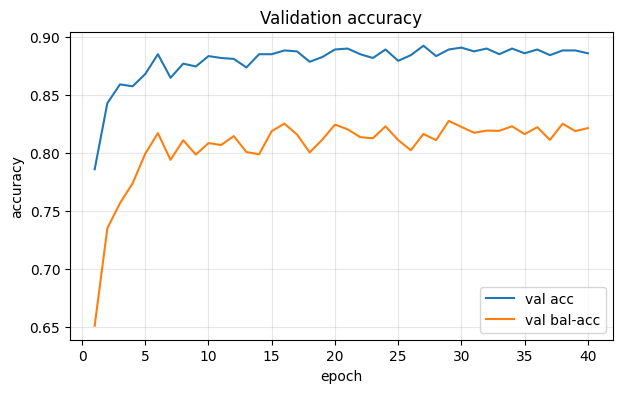

In [4]:
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate(loader):
    model.eval(); ys, ps = [], []
    for imgs, labels in loader:
        out, _, _ = model(imgs.to(DEVICE))
        ps.append(out.argmax(1).cpu()); ys.append(labels)
    y, p = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return float((p == y).mean()), float(balanced_accuracy_score(y, p)), y, p

os.makedirs('/kaggle/working/ckpt', exist_ok=True)
BEST = '/kaggle/working/ckpt/ddamfn_rafdb_best.pth'
best_val = 0.0; history = []

for ep in range(1, CFG['epochs'] + 1):
    model.train(); running = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        # ---- SAM ascent step ----
        out, _, heads = model(imgs)
        loss = criterion_cls(out, labels) + 0.1 * criterion_at(heads)
        loss.backward(); optimizer.first_step(zero_grad=True)
        # ---- SAM descent step ----
        out2, _, heads2 = model(imgs)
        (criterion_cls(out2, labels) + 0.1 * criterion_at(heads2)).backward()
        optimizer.second_step(zero_grad=True)
        running += loss.item()
    scheduler.step()
    va, vb, *_ = evaluate(val_loader)
    history.append((ep, running / len(train_loader), va, vb))
    print(f'epoch {ep:2d}/{CFG["epochs"]} | loss {running/len(train_loader):.3f} | val_acc {va:.4f} | val_bacc {vb:.4f}')
    if va > best_val:
        best_val = va
        torch.save({'epoch': ep, 'model_state_dict': model.state_dict(), 'val_acc': va}, BEST)
        print(f'   * new best val_acc {va:.4f} — checkpoint saved')

print(f'\nBest validation accuracy: {best_val:.4f}')

h = np.array(history)
plt.figure(figsize=(7, 4))
plt.plot(h[:, 0], h[:, 2], label='val acc')
plt.plot(h[:, 0], h[:, 3], label='val bal-acc')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.title('Validation accuracy')
plt.legend(); plt.grid(alpha=.3); plt.show()

## 5 · Final evaluation — once, on the full 3,068-image test set

This is the **only** place the test set is used. We report overall + mean-class accuracy, the full
per-class report, the 3- / 5-scale sentiment accuracies, and the confusion matrix.

   DDAMFN | RAF-DB | test results
7-class OVERALL accuracy     : 91.07%
7-class MEAN-CLASS (balanced): 84.64%

              precision    recall  f1-score   support

    Surprise     0.8951    0.8815    0.8882       329
        Fear     0.7692    0.6757    0.7194        74
     Disgust     0.7919    0.7375    0.7638       160
   Happiness     0.9648    0.9705    0.9676      1185
     Sadness     0.8938    0.8808    0.8872       478
       Anger     0.9145    0.8580    0.8854       162
     Neutral     0.8755    0.9206    0.8975       680

    accuracy                         0.9107      3068
   macro avg     0.8721    0.8464    0.8584      3068
weighted avg     0.9101    0.9107    0.9101      3068

3-scale (valence) accuracy : 92.89%
5-scale accuracy           : 92.11%


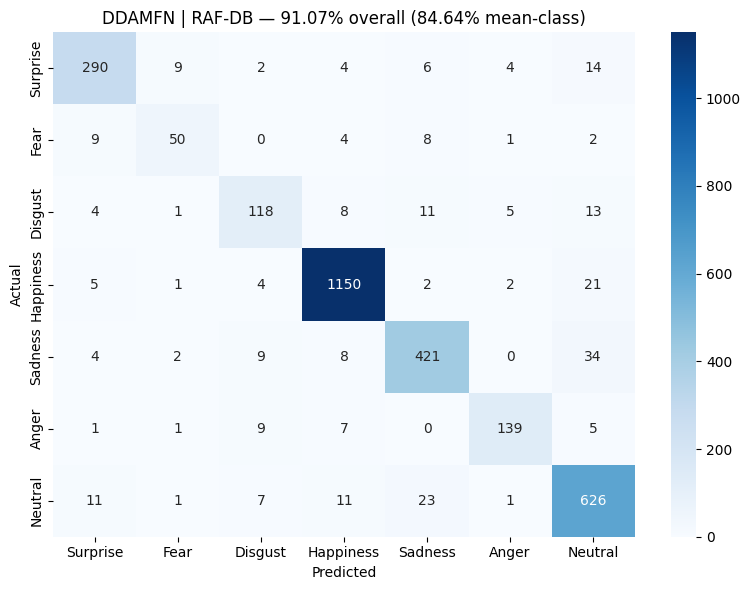

In [5]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load(BEST)['model_state_dict'])
acc, bacc, y, p = evaluate(test_loader)

print('=' * 48)
print('   DDAMFN | RAF-DB | test results')
print('=' * 48)
print(f'7-class OVERALL accuracy     : {acc*100:.2f}%')
print(f'7-class MEAN-CLASS (balanced): {bacc*100:.2f}%\n')
print(classification_report(y, p, target_names=CLASS_NAMES, digits=4))

# one consistent sentiment-scale mapping (label space 0=Surprise .. 6=Neutral)
to3 = {0: 2, 3: 2, 6: 1, 1: 0, 2: 0, 4: 0, 5: 0}   # 2=Positive{Surprise,Happiness} 1=Neutral 0=Negative{rest}
to5 = {0: 0, 1: 0, 2: 1, 5: 1, 3: 2, 4: 3, 6: 4}   # {Surprise,Fear} {Disgust,Anger} Happiness Sadness Neutral
vec = np.vectorize
acc3 = float((vec(to3.get)(y) == vec(to3.get)(p)).mean())
acc5 = float((vec(to5.get)(y) == vec(to5.get)(p)).mean())
print(f'3-scale (valence) accuracy : {acc3*100:.2f}%')
print(f'5-scale accuracy           : {acc5*100:.2f}%')

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y, p), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'DDAMFN | RAF-DB — {acc*100:.2f}% overall ({bacc*100:.2f}% mean-class)')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

## 6 · Save model & results

In [7]:
results = {
    'model'         : f"DDAMFN (MFN/MS-Celeb backbone, num_head={CFG['num_head']})",
    'dataset'       : 'RAF-DB basic (12,271 train / 3,068 test)',
    'protocol'      : 'val carved from train; test evaluated once; overall + mean-class',
    'overall_acc'   : round(acc * 100, 2),
    'mean_class_acc': round(bacc * 100, 2),
    'acc_3scale'    : round(acc3 * 100, 2),
    'acc_5scale'    : round(acc5 * 100, 2),
    'epochs'        : CFG['epochs'],
    'best_val_acc'  : round(best_val * 100, 2),
}
with open('/kaggle/working/ddamfn_results.json', 'w') as f:
    json.dump(results, f, indent=2)
torch.save({'model_state_dict': model.state_dict(), 'class_names': CLASS_NAMES, 'cfg': CFG},
           '/kaggle/working/ddamfn_rafdb_final.pth')
print(json.dumps(results, indent=2))
print('\nSaved -> ddamfn_rafdb_final.pth, ddamfn_results.json  (Output tab to download)')

{
  "model": "DDAMFN (MFN/MS-Celeb backbone, num_head=2)",
  "dataset": "RAF-DB basic (12,271 train / 3,068 test)",
  "protocol": "val carved from train; test evaluated once; overall + mean-class",
  "overall_acc": 91.07,
  "mean_class_acc": 84.64,
  "acc_3scale": 92.89,
  "acc_5scale": 92.11,
  "epochs": 40,
  "best_val_acc": 89.25
}

Saved -> ddamfn_rafdb_final.pth, ddamfn_results.json  (Output tab to download)


## 7 · (Optional) Predict on a single image

For your **own** photos, faces should be cropped/aligned first (RAF-DB images are pre-aligned). A
common choice is `facenet-pytorch`'s MTCNN; here we keep it dependency-free and demo on a test image.

In [9]:
@torch.no_grad()
def predict_image(path):
    model.eval()
    img = Image.open(path).convert('RGB')
    x = eval_tf(img).unsqueeze(0).to(DEVICE)
    out, _, _ = model(x)
    prob = F.softmax(out, 1)[0].cpu().numpy()
    order = prob.argsort()[::-1]
    print(f'Prediction: {CLASS_NAMES[order[0]]}  ({prob[order[0]]*100:.1f}%)')
    for k in order:
        print(f'   {CLASS_NAMES[k]:10s} {prob[k]*100:5.1f}%')
    return CLASS_NAMES[order[0]]

# demo on one test image
sample = test_df.iloc[0]
print('true label:', CLASS_NAMES[int(sample['label']) - 1])
predict_image(IMG[sample['image']])

true label: Sadness
Prediction: Sadness  (100.0%)
   Sadness    100.0%
   Fear         0.0%
   Disgust      0.0%
   Anger        0.0%
   Surprise     0.0%
   Neutral      0.0%
   Happiness    0.0%


'Sadness'

## Notes
- Reported numbers are overall and mean-class accuracy on the official RAF-DB test split.
- Possible extensions: train longer (`epochs=60`), try `num_head=4`, or ensemble with a second model.
- Leaderboard context: POSTER++ 92.21%, DDAMFN 91.35%, current top ~94% (Ig3D, 2024).